# Phillips Curve - US Economy

Objective: build the first version of a Phillips curve project for the United States using monthly macroeconomic data.

We will use unemployment as the labor-market variable and CPI inflation as the price variable. The data source is FRED, using `UNRATE` for the unemployment rate and `CPIAUCSL` for the CPI index. Inflation is calculated as year-over-year percentage change in CPI, which is a common way to make monthly inflation data less noisy.

Time range note: the project starts with the last 10 years because the user requested a recent sample. For Phillips curve modeling, this is useful for a modern view, but it is also a short sample and includes unusual shocks such as COVID-19 and the 2021-2023 inflation surge. Many empirical papers use longer samples, quarterly frequency, unemployment gaps, inflation expectations, or lagged inflation. So this notebook is a clean first step for data import, visualization, and stationarity testing, not the final structural model.

References for the modeling direction:
- FRED series: `UNRATE` and `CPIAUCSL`.
- Recent Phillips curve literature often emphasizes instability over time, lagged inflation or expectations, and labor-market slack rather than the raw unemployment rate.

## 1. Import packages

Here, we are importing the packages needed for the project. `pandas` and `numpy` help us organize and transform the data, `matplotlib` and `seaborn` help us plot the series, and `statsmodels` gives us the regression tools, stationarity tests, diagnostic tests, and Granger-predictive causality tests used later in the notebook.


In [24]:
from datetime import date
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Choose the sample period

Here, we are defining the sample period. We download one extra year of CPI data because year-over-year inflation needs 12 previous monthly observations. After calculating inflation, we keep only the last 10 years for the final analysis.

In [25]:
today = pd.Timestamp(date.today())
analysis_start = (today - pd.DateOffset(years=10)).to_period("M").to_timestamp()
download_start = analysis_start - pd.DateOffset(years=1)

analysis_start, download_start

(Timestamp('2016-05-01 00:00:00'), Timestamp('2015-05-01 00:00:00'))

## 3. Import data from FRED

Here, we are importing data from FRED. `UNRATE` is the US unemployment rate, `CPIAUCSL` is the headline CPI index, `CPILFESL` is the core CPI index, and `NROU` is the Congressional Budget Office estimate of the natural rate of unemployment. We use FRED CSV links directly, so this notebook does not require an API key.

In [26]:
fred_series = {
    "unemployment_rate": "UNRATE",
    "cpi": "CPIAUCSL",
    "core_cpi": "CPILFESL",
    "natural_rate": "NROU",
}

def read_fred_csv(series_id, start_date):
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv?"
        f"id={series_id}&observation_start={start_date:%Y-%m-%d}"
    )
    data = pd.read_csv(url)
    data["observation_date"] = pd.to_datetime(data["observation_date"])
    data = data.rename(columns={"observation_date": "date", series_id: series_id.lower()})
    data[series_id.lower()] = pd.to_numeric(data[series_id.lower()], errors="coerce")
    return data.set_index("date")

unrate = read_fred_csv(fred_series["unemployment_rate"], download_start)
cpi = read_fred_csv(fred_series["cpi"], download_start)
core_cpi = read_fred_csv(fred_series["core_cpi"], download_start)
natural_rate = read_fred_csv(fred_series["natural_rate"], download_start)

raw_data = unrate.join([cpi, core_cpi, natural_rate], how="outer").sort_index()
raw_data["nrou"] = raw_data["nrou"].ffill()
raw_data = raw_data.dropna(subset=["unrate", "cpiaucsl", "cpilfesl", "nrou"])
raw_data.tail()

,unrate,cpiaucsl,cpilfesl,nrou
date,,,,
2025-12-01,4.4,326.031,331.814,4.401841
2026-01-01,4.3,326.588,332.793,4.399091
2026-02-01,4.4,327.460,333.512,4.399091
2026-03-01,4.3,330.293,334.165,4.399091
2026-04-01,4.3,332.407,335.423,4.395932


## 4. Build inflation and final dataset

Here, we are transforming the CPI indexes into inflation rates. The formula is the year-over-year percentage change: current CPI divided by CPI 12 months before, minus 1, multiplied by 100. We also build the unemployment gap as the unemployment rate minus the natural rate of unemployment. Finally, we create the squared unemployment gap, which allows us to test a curved Phillips curve instead of forcing the relationship to be a straight line.


In [27]:
data = raw_data.copy()
data["inflation_yoy"] = data["cpiaucsl"].pct_change(12, fill_method=None) * 100
data["core_inflation_yoy"] = data["cpilfesl"].pct_change(12, fill_method=None) * 100
data = data.rename(columns={"unrate": "unemployment_rate"})
data["unemployment_gap"] = data["unemployment_rate"] - data["nrou"]
data["unemployment_gap_squared"] = data["unemployment_gap"] ** 2
data["inflation_yoy_lag1"] = data["inflation_yoy"].shift(1)
data["core_inflation_yoy_lag1"] = data["core_inflation_yoy"].shift(1)
data["covid_dummy"] = ((data.index >= "2020-03-01") & (data.index <= "2021-12-01")).astype(int)

columns_to_keep = [
    "unemployment_rate",
    "nrou",
    "unemployment_gap",
    "unemployment_gap_squared",
    "inflation_yoy",
    "core_inflation_yoy",
    "inflation_yoy_lag1",
    "core_inflation_yoy_lag1",
    "covid_dummy",
]

monthly_data = data.loc[data.index >= analysis_start, columns_to_keep].dropna()

print(f"Sample starts: {monthly_data.index.min():%Y-%m}")
print(f"Sample ends:   {monthly_data.index.max():%Y-%m}")
print(f"Observations:  {len(monthly_data)}")

monthly_data.head()

Sample starts: 2016-05
Sample ends:   2026-04
Observations:  119


,unemployment_rate,nrou,unemployment_gap,unemployment_gap_squared,inflation_yoy,core_inflation_yoy,inflation_yoy_lag1,core_inflation_yoy_lag1,covid_dummy
date,,,,,,,,,
2016-05-01,4.8,4.644316,0.155684,0.024237,1.078476,2.254560,1.172626,2.156655,0
2016-06-01,4.9,4.644316,0.255684,0.065374,1.079287,2.262212,1.078476,2.254560,0
2016-07-01,4.8,4.625558,0.174442,0.030430,0.868363,2.170140,1.079287,2.262212,0
2016-08-01,4.9,4.625558,0.274442,0.075319,1.055316,2.308735,0.868363,2.170140,0
2016-09-01,5.0,4.625558,0.374442,0.140207,1.548645,2.271121,1.055316,2.308735,0


## 5. Plot unemployment and inflation

Here, we are plotting both variables through time. This helps us visually inspect the dynamics before estimating a Phillips curve. In particular, we want to see whether the series have trends, sudden shocks, or periods where unemployment and inflation move in opposite directions.

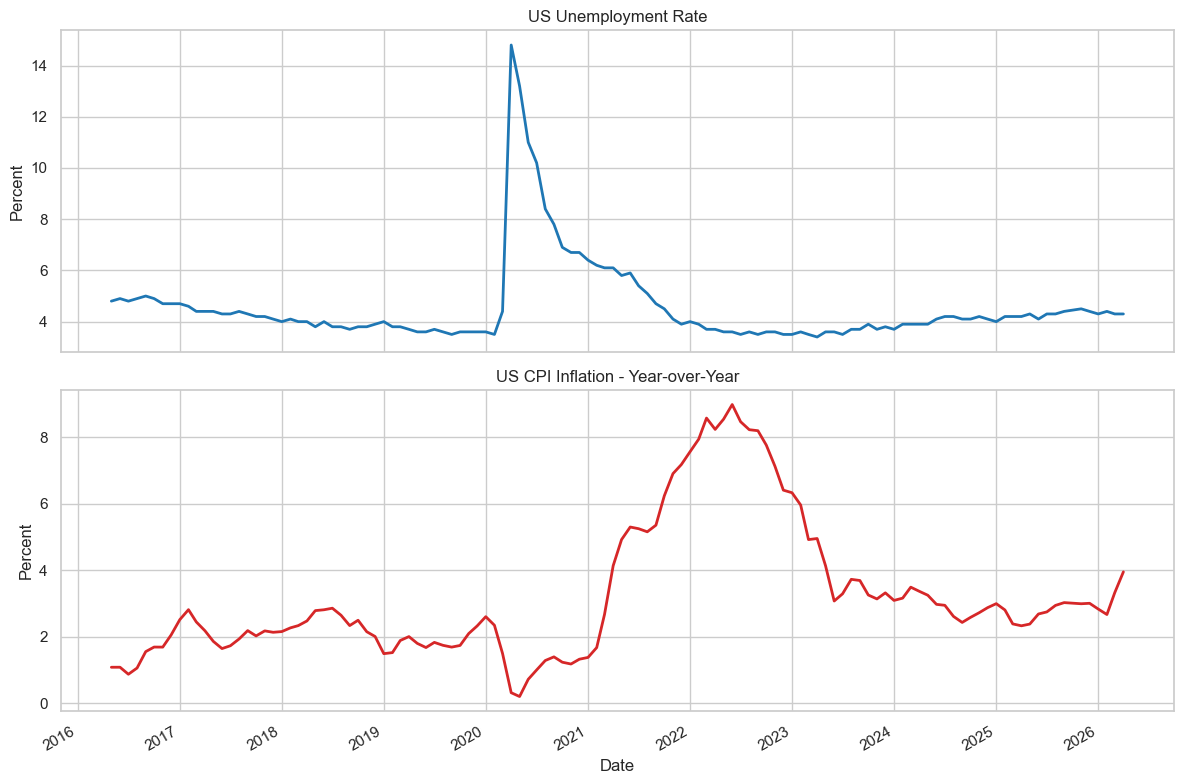

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

monthly_data["unemployment_rate"].plot(ax=axes[0], color="#1f77b4", linewidth=2)
axes[0].set_title("US Unemployment Rate")
axes[0].set_ylabel("Percent")

monthly_data["inflation_yoy"].plot(ax=axes[1], color="#d62728", linewidth=2)
axes[1].set_title("US CPI Inflation - Year-over-Year")
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 6. Plot the first Phillips curve scatter

Here, we are plotting inflation against unemployment with a simple linear fitted line. This is only a first diagnostic. A straight line is easy to read, but the Phillips curve can be non-linear, so later we will compare this with a quadratic form.


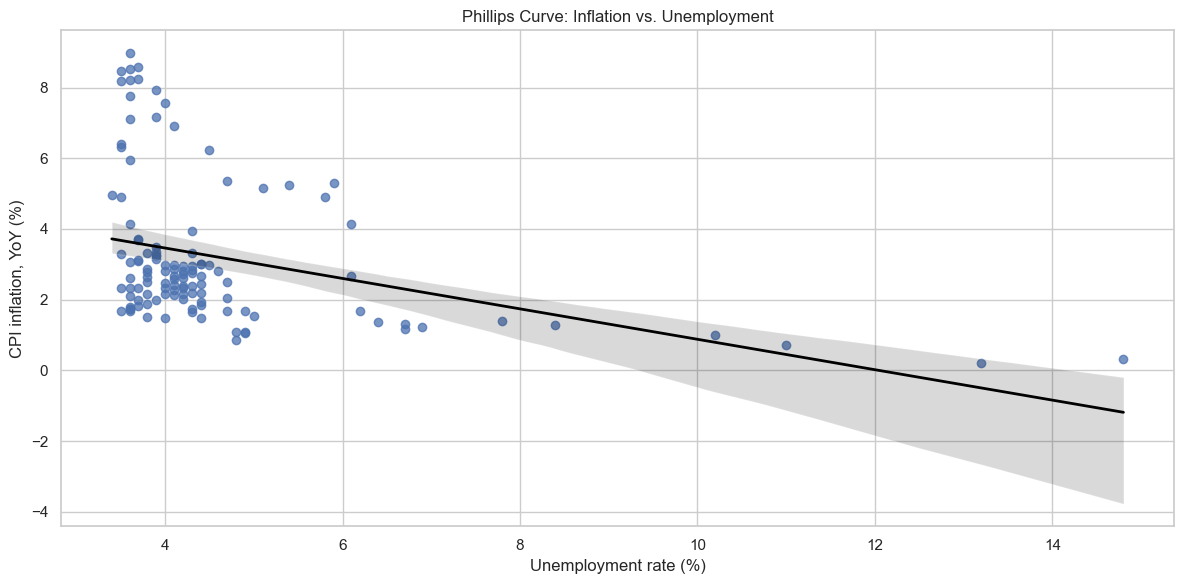

In [29]:
ax = sns.regplot(
    data=monthly_data,
    x="unemployment_rate",
    y="inflation_yoy",
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "black", "linewidth": 2},
)

ax.set_title("Phillips Curve: Inflation vs. Unemployment")
ax.set_xlabel("Unemployment rate (%)")
ax.set_ylabel("CPI inflation, YoY (%)")
plt.tight_layout()
plt.show()

## 7. Test stationarity

Here, we are testing whether each variable is stationary. We use two tests because they have opposite null hypotheses. The ADF test has a null hypothesis of non-stationarity, while the KPSS test has a null hypothesis of stationarity. Reading both together gives a more balanced view.

In [30]:
def stationarity_tests(series, name):
    clean_series = series.dropna()

    adf_stat, adf_pvalue, _, _, adf_critical, _ = adfuller(clean_series, autolag="AIC")
    kpss_stat, kpss_pvalue, _, kpss_critical = kpss(clean_series, regression="c", nlags="auto")

    return {
        "variable": name,
        "adf_statistic": adf_stat,
        "adf_p_value": adf_pvalue,
        "adf_5pct_critical": adf_critical["5%"],
        "adf_interpretation": "stationary" if adf_pvalue < 0.05 else "not stationary",
        "kpss_statistic": kpss_stat,
        "kpss_p_value": kpss_pvalue,
        "kpss_5pct_critical": kpss_critical["5%"],
        "kpss_interpretation": "not stationary" if kpss_pvalue < 0.05 else "stationary",
    }

stationarity_results = pd.DataFrame([
    stationarity_tests(monthly_data["unemployment_rate"], "Unemployment rate"),
    stationarity_tests(monthly_data["unemployment_gap"], "Unemployment gap"),
    stationarity_tests(monthly_data["inflation_yoy"], "Inflation YoY"),
    stationarity_tests(monthly_data["core_inflation_yoy"], "Core inflation YoY"),
])

stationarity_results

C:\Users\vinic\AppData\Local\Temp\ipykernel_23248\1155886547.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_critical = kpss(clean_series, regression="c", nlags="auto")
C:\Users\vinic\AppData\Local\Temp\ipykernel_23248\1155886547.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, _, kpss_critical = kpss(clean_series, regression="c", nlags="auto")


,variable,adf_statistic,adf_p_value,adf_5pct_critical,adf_interpretation,kpss_statistic,kpss_p_value,kpss_5pct_critical,kpss_interpretation
0,Unemployment rate,-3.334567,0.013402,-2.886363,stationary,0.177791,0.100000,0.463,stationary
1,Unemployment gap,-3.335706,0.013356,-2.886363,stationary,0.161129,0.100000,0.463,stationary
2,Inflation YoY,-2.057710,0.261856,-2.889485,not stationary,0.466753,0.049155,0.463,not stationary
3,Core inflation YoY,-1.999926,0.286606,-2.889485,not stationary,0.700110,0.013535,0.463,not stationary


## 8. Descriptive statistics

Here, we are summarizing the variables we created so far. This table helps us check the scale and variation of unemployment, inflation, core inflation, the unemployment gap, and the COVID-period indicator before estimating the models.

In [31]:
summary = monthly_data.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
unemployment_rate,119.0,4.563025,1.730135,3.400000e+00,3.700000,4.100000,4.450000,14.800000
nrou,119.0,4.471764,0.062816,4.395932e+00,4.430096,4.449790,4.498416,4.644316
unemployment_gap,119.0,0.091261,1.729750,-1.033510e+00,-0.731368,-0.344656,0.005257,10.340952
unemployment_gap_squared,119.0,2.975219,12.908439,8.270735e-07,0.066200,0.296391,0.754608,106.935291
inflation_yoy,119.0,3.218883,2.064498,1.982013e-01,1.869765,2.642924,3.423815,8.979361
core_inflation_yoy,119.0,3.124122,1.460074,1.183684e+00,2.121839,2.673098,3.927582,6.624288
inflation_yoy_lag1,119.0,3.195569,2.071858,1.982013e-01,1.841337,2.607144,3.340500,8.979361
core_inflation_yoy_lag1,119.0,3.117132,1.462718,1.183684e+00,2.121839,2.367661,3.927582,6.624288
covid_dummy,119.0,0.184874,0.389837,0.000000e+00,0.000000,0.000000,0.000000,1.000000


## 9. Plot the unemployment gap and core inflation

Here, we are plotting two improved variables for the Phillips curve. The unemployment gap measures labor-market slack relative to the natural rate, while core inflation removes food and energy prices, which can be volatile and less connected to domestic labor-market pressure.

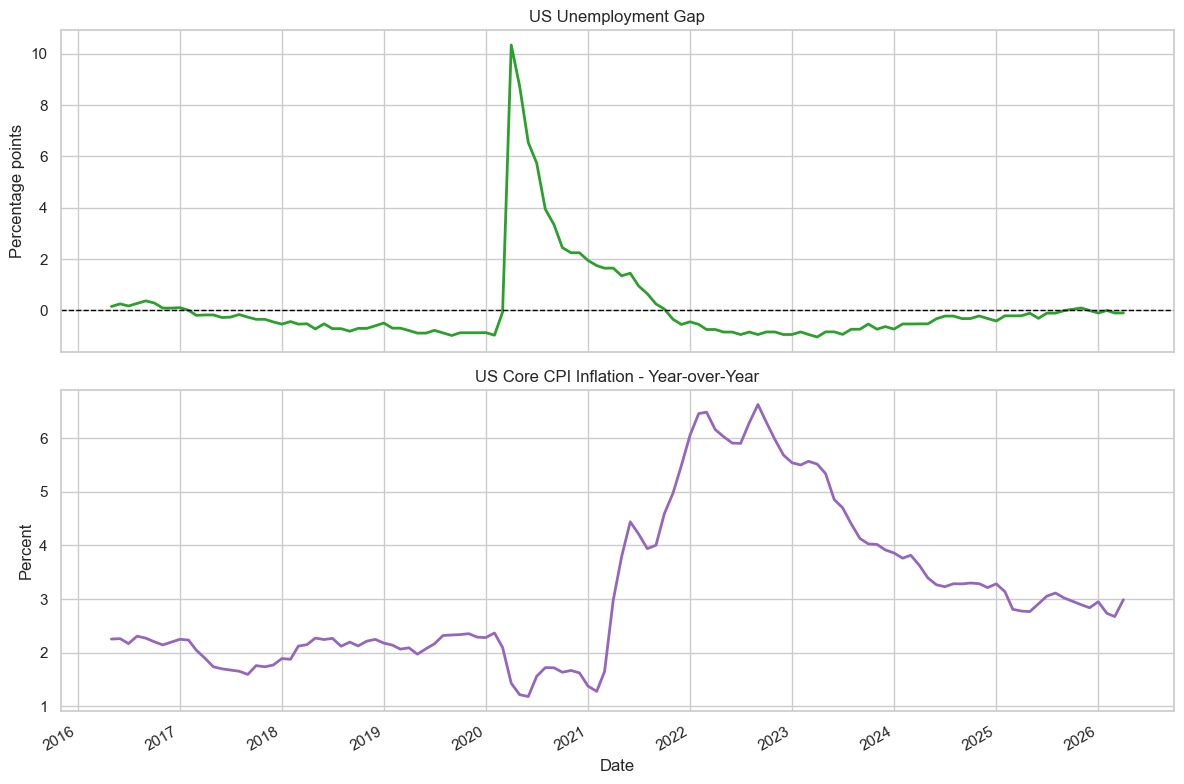

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

monthly_data["unemployment_gap"].plot(ax=axes[0], color="#2ca02c", linewidth=2)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("US Unemployment Gap")
axes[0].set_ylabel("Percentage points")

monthly_data["core_inflation_yoy"].plot(ax=axes[1], color="#9467bd", linewidth=2)
axes[1].set_title("US Core CPI Inflation - Year-over-Year")
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 10. Compare linear and quadratic Phillips curve shapes

Here, we are comparing two possible shapes for the Phillips curve. The linear fit assumes that each 1 percentage point change in the unemployment gap has the same inflation association at every level of slack. The quadratic fit allows the curve to bend, which may be more realistic when the labor market is extremely tight or extremely weak.


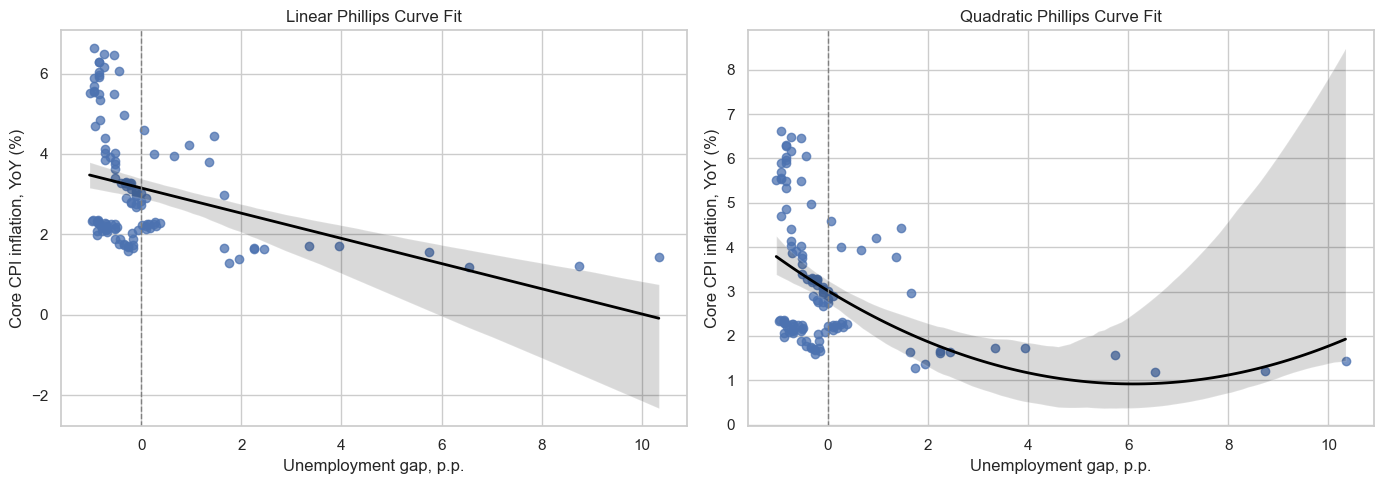

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=monthly_data,
    x="unemployment_gap",
    y="core_inflation_yoy",
    ax=axes[0],
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "black", "linewidth": 2},
)
axes[0].axvline(0, color="gray", linewidth=1, linestyle="--")
axes[0].set_title("Linear Phillips Curve Fit")
axes[0].set_xlabel("Unemployment gap, p.p.")
axes[0].set_ylabel("Core CPI inflation, YoY (%)")

sns.regplot(
    data=monthly_data,
    x="unemployment_gap",
    y="core_inflation_yoy",
    ax=axes[1],
    order=2,
    scatter_kws={"alpha": 0.75},
    line_kws={"color": "black", "linewidth": 2},
)
axes[1].axvline(0, color="gray", linewidth=1, linestyle="--")
axes[1].set_title("Quadratic Phillips Curve Fit")
axes[1].set_xlabel("Unemployment gap, p.p.")
axes[1].set_ylabel("Core CPI inflation, YoY (%)")

plt.tight_layout()
plt.show()


## 11. Estimate Phillips curve models

Here, we are estimating four Phillips curve specifications with OLS. Model 1 is the simplest version, using only the unemployment rate. Model 2 replaces unemployment with the unemployment gap. Model 3 adds lagged core inflation, which captures inflation persistence. Model 4 adds the squared unemployment gap, allowing the Phillips curve to be quadratic instead of strictly linear.


In [34]:
def fit_ols(y_column, x_columns, data_frame):
    model_data = data_frame[[y_column] + x_columns].dropna()
    y = model_data[y_column]
    x = sm.add_constant(model_data[x_columns])
    return sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

models = {
    "1_simple_unemployment": fit_ols("inflation_yoy", ["unemployment_rate"], monthly_data),
    "2_unemployment_gap": fit_ols("inflation_yoy", ["unemployment_gap"], monthly_data),
    "3_augmented_core_linear": fit_ols(
        "core_inflation_yoy",
        ["unemployment_gap", "core_inflation_yoy_lag1"],
        monthly_data,
    ),
    "4_augmented_core_quadratic": fit_ols(
        "core_inflation_yoy",
        ["unemployment_gap", "unemployment_gap_squared", "core_inflation_yoy_lag1"],
        monthly_data,
    ),
}

model_summary = pd.DataFrame({
    name: {
        "observations": int(model.nobs),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "aic": model.aic,
        "bic": model.bic,
    }
    for name, model in models.items()
}).T

model_summary


,observations,r_squared,adj_r_squared,aic,bic
1_simple_unemployment,119.0,0.130081,0.122645,496.643071,502.201318
2_unemployment_gap,119.0,0.120314,0.112795,497.971639,503.529886
3_augmented_core_linear,119.0,0.971609,0.971120,8.942062,17.279432
4_augmented_core_quadratic,119.0,0.975006,0.974354,-4.224434,6.892060


## 12. Read the estimated coefficients

Here, we are organizing the regression coefficients, standard errors, and p-values. The key Phillips curve coefficient is the coefficient on unemployment or the unemployment gap. In a linear model, a coefficient of `-0.20` would mean that a 1 percentage point higher unemployment gap is associated with 0.20 percentage points lower inflation, holding the other model variables constant. This is an association, not proof that unemployment caused inflation to move by exactly that amount.


In [35]:
coefficient_tables = []

for model_name, model in models.items():
    table = pd.DataFrame({
        "model": model_name,
        "coefficient": model.params,
        "std_error_hac": model.bse,
        "p_value": model.pvalues,
    })
    coefficient_tables.append(table.reset_index(names="variable"))

coefficients = pd.concat(coefficient_tables, ignore_index=True)
coefficients

,variable,model,coefficient,std_error_hac,p_value
0,const,1_simple_unemployment,5.182666,1.246729,3.224366e-05
1,unemployment_rate,1_simple_unemployment,-0.430369,0.161265,7.614561e-03
2,const,2_unemployment_gap,3.256665,0.584485,2.520440e-08
3,unemployment_gap,2_unemployment_gap,-0.413989,0.153910,7.149217e-03
4,const,3_augmented_core_linear,0.072922,0.054705,1.825299e-01
5,unemployment_gap,3_augmented_core_linear,-0.010845,0.020638,5.992533e-01
6,core_inflation_yoy_lag1,3_augmented_core_linear,0.979166,0.022500,0.000000e+00
7,const,4_augmented_core_quadratic,0.045595,0.051087,3.721287e-01
8,unemployment_gap,4_augmented_core_quadratic,0.097186,0.038104,1.075487e-02
9,unemployment_gap_squared,4_augmented_core_quadratic,-0.015299,0.004396,5.011586e-04


## 13. Compare the full sample with a sample excluding COVID

Here, we are checking whether the extraordinary COVID period changes the Phillips curve estimates. We estimate the same quadratic augmented core-inflation model twice: once with all observations and once excluding March 2020 through December 2021.


In [36]:
non_covid_data = monthly_data.loc[monthly_data["covid_dummy"] == 0].copy()

augmented_full = fit_ols(
    "core_inflation_yoy",
    ["unemployment_gap", "unemployment_gap_squared", "core_inflation_yoy_lag1"],
    monthly_data,
)

augmented_ex_covid = fit_ols(
    "core_inflation_yoy",
    ["unemployment_gap", "unemployment_gap_squared", "core_inflation_yoy_lag1"],
    non_covid_data,
)

covid_comparison = pd.DataFrame({
    "full_sample": augmented_full.params,
    "full_sample_p_value": augmented_full.pvalues,
    "excluding_covid": augmented_ex_covid.params,
    "excluding_covid_p_value": augmented_ex_covid.pvalues,
})

covid_comparison


,full_sample,full_sample_p_value,excluding_covid,excluding_covid_p_value
const,0.045595,0.372129,0.036877,0.399904
unemployment_gap,0.097186,0.010755,-0.020440,0.799375
unemployment_gap_squared,-0.015299,0.000501,-0.022607,0.840658
core_inflation_yoy_lag1,0.999372,0.000000,0.980897,0.000000


## 14. Basic model diagnostics

Here, we are running simple residual diagnostics for the augmented model. The Breusch-Godfrey test checks residual autocorrelation, and the Breusch-Pagan test checks heteroskedasticity. These tests help us understand whether the OLS residuals behave cleanly or whether we need richer time-series methods.

In [37]:
diagnostic_model = models["4_augmented_core_quadratic"]

bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(diagnostic_model, nlags=12)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(diagnostic_model.resid, diagnostic_model.model.exog)

diagnostics = pd.DataFrame({
    "test": ["Breusch-Godfrey autocorrelation", "Breusch-Pagan heteroskedasticity"],
    "statistic": [bg_stat, bp_stat],
    "p_value": [bg_pvalue, bp_pvalue],
})

diagnostics

,test,statistic,p_value
0,Breusch-Godfrey autocorrelation,59.511227,2.770938e-08
1,Breusch-Pagan heteroskedasticity,14.252530,2.580811e-03


## 15. Test predictive causality with Granger tests

Here, we are testing predictive causality, often called Granger causality. This does not prove true economic causality. It only asks whether past values of one variable help predict current values of another variable. For example, if past unemployment gaps help predict current core inflation, the test may suggest useful forecasting information, but it still does not prove that unemployment directly caused inflation to change.


In [38]:
granger_data = monthly_data[["core_inflation_yoy", "unemployment_gap"]].dropna()
max_lag = 6

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    gap_predicts_inflation = grangercausalitytests(
        granger_data[["core_inflation_yoy", "unemployment_gap"]],
        maxlag=max_lag,
        verbose=False,
    )

    inflation_predicts_gap = grangercausalitytests(
        granger_data[["unemployment_gap", "core_inflation_yoy"]],
        maxlag=max_lag,
        verbose=False,
    )

granger_results = pd.DataFrame({
    "lag_months": range(1, max_lag + 1),
    "unemployment_gap_predicts_core_inflation_p_value": [
        gap_predicts_inflation[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)
    ],
    "core_inflation_predicts_unemployment_gap_p_value": [
        inflation_predicts_gap[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)
    ],
})

best_gap_to_inflation_p = granger_results["unemployment_gap_predicts_core_inflation_p_value"].min()
best_inflation_to_gap_p = granger_results["core_inflation_predicts_unemployment_gap_p_value"].min()

print(f"Best p-value for unemployment gap predicting core inflation: {best_gap_to_inflation_p:.4f}")
print(f"Best p-value for core inflation predicting unemployment gap: {best_inflation_to_gap_p:.4f}")
print("Interpretation: values below 0.05 would be stronger evidence of predictive causality; higher values suggest weak evidence.")

granger_results


Best p-value for unemployment gap predicting core inflation: 0.2999
Best p-value for core inflation predicting unemployment gap: 0.2240
Interpretation: values below 0.05 would be stronger evidence of predictive causality; higher values suggest weak evidence.


,lag_months,unemployment_gap_predicts_core_inflation_p_value,core_inflation_predicts_unemployment_gap_p_value
0,1,0.299935,0.224026
1,2,0.399837,0.342495
2,3,0.459416,0.304345
3,4,0.563879,0.398909
4,5,0.535477,0.564994
5,6,0.627268,0.653084


## 16. Generate first economic insights

Here, we are turning the model estimates into a short economic interpretation. The goal is to make the output readable for stakeholders: what changed, how large is the estimated association, and what we should not overclaim. In particular, regression coefficients are practical associations, not automatic causal effects.


In [39]:
linear_model = models["3_augmented_core_linear"]
quadratic_model = models["4_augmented_core_quadratic"]

linear_gap_coefficient = linear_model.params["unemployment_gap"]
linear_gap_pvalue = linear_model.pvalues["unemployment_gap"]
quadratic_gap_coefficient = quadratic_model.params["unemployment_gap"]
quadratic_gap_squared_coefficient = quadratic_model.params["unemployment_gap_squared"]
quadratic_gap_pvalue = quadratic_model.pvalues["unemployment_gap"]
quadratic_gap_squared_pvalue = quadratic_model.pvalues["unemployment_gap_squared"]
lag_coefficient = quadratic_model.params["core_inflation_yoy_lag1"]
lag_pvalue = quadratic_model.pvalues["core_inflation_yoy_lag1"]

latest_gap = monthly_data["unemployment_gap"].iloc[-1]
marginal_effect_latest = quadratic_gap_coefficient + 2 * quadratic_gap_squared_coefficient * latest_gap
marginal_effect_normal = quadratic_gap_coefficient

def effect_text(value):
    direction = "lower" if value < 0 else "higher"
    return f"{abs(value):.3f} percentage points {direction}"

linear_significance = "statistically significant" if linear_gap_pvalue < 0.05 else "not statistically significant"
quadratic_significance = "statistically significant" if quadratic_gap_squared_pvalue < 0.05 else "not statistically significant"
lag_significance = "statistically significant" if lag_pvalue < 0.05 else "not statistically significant"

print("First Phillips curve insights")
print("-----------------------------")
print(f"Linear model: a 1 percentage point higher unemployment gap is associated with {effect_text(linear_gap_coefficient)} core inflation, holding lagged inflation constant.")
print(f"The p-value is {linear_gap_pvalue:.4f}, so this linear gap effect is {linear_significance} at the 5% level.")
print(f"Quadratic model: the squared-gap term has coefficient {quadratic_gap_squared_coefficient:.4f} and p-value {quadratic_gap_squared_pvalue:.4f}; it is {quadratic_significance} at the 5% level.")
print(f"At the latest unemployment gap ({latest_gap:.2f} p.p.), a 1 percentage point higher gap is associated with {effect_text(marginal_effect_latest)} core inflation, holding lagged inflation constant.")
print(f"Around a normal labor market, where the unemployment gap equals zero, the model-implied association is {effect_text(marginal_effect_normal)}.")
print(f"The lagged core-inflation coefficient is {lag_coefficient:.4f}, with p-value {lag_pvalue:.4f}; inflation persistence is {lag_significance} at the 5% level.")
print("Important: these are model-implied associations, not proof of causality. A move from 4% to 5% unemployment is a 1 percentage point increase, not a 1% increase.")


First Phillips curve insights
-----------------------------
Linear model: a 1 percentage point higher unemployment gap is associated with 0.011 percentage points lower core inflation, holding lagged inflation constant.
The p-value is 0.5993, so this linear gap effect is not statistically significant at the 5% level.
Quadratic model: the squared-gap term has coefficient -0.0153 and p-value 0.0005; it is statistically significant at the 5% level.
At the latest unemployment gap (-0.10 p.p.), a 1 percentage point higher gap is associated with 0.100 percentage points higher core inflation, holding lagged inflation constant.
Around a normal labor market, where the unemployment gap equals zero, the model-implied association is 0.097 percentage points higher.
The lagged core-inflation coefficient is 0.9994, with p-value 0.0000; inflation persistence is statistically significant at the 5% level.
Important: these are model-implied associations, not proof of causality. A move from 4% to 5% unempl